In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util.load import DataLoader

In [154]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 250
full_df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="processed"
)
daily_df = dataloader.load_daily_data(ticker, max_days=max_days, type_="processed")
full_df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2025-05-26: 100%|██████████| 250/250 [00:00<00:00, 258.21it/s]


,time_to_strike,count,shift,kalshi_fair,yes_price,no_price,taker_side,day_forecast_high,day_forecast_strike_dev,current_forecast_strike_dev,...,hour_forecast_rain,strike_m_5.0,strike_m_3.0,strike_m_1.0,strike_p_1.0,strike_p_3.0,strike_p_5.0,impact,result,outcome
0,134545.825,2,3.0,78.5,44,56,1,84.4,5.9,-9.6,...,0.0,0,0,0,0,44,0,-42.992,-44,0
1,134545.825,1,3.0,78.5,44,56,1,84.4,5.9,-9.6,...,0.0,0,0,0,0,44,0,-43.000,-44,0
2,134545.825,1,3.0,78.5,43,57,1,84.4,5.9,-9.6,...,0.0,0,0,0,0,43,0,-42.000,-43,0
3,134325.595,3,3.0,78.5,43,57,0,84.4,5.9,-9.6,...,0.0,0,0,0,0,43,0,41.931,43,0
4,134325.595,40,3.0,78.5,46,54,0,84.4,5.9,-9.6,...,0.0,0,0,0,0,46,0,44.918,46,0


In [155]:
full_df.columns

Index(['time', 'trade_id', 'ticker', 'time_to_strike', 'count', 'shift',
       'kalshi_fair', 'yes_price', 'no_price', 'taker_side',
       'day_forecast_high', 'day_forecast_strike_dev',
       'current_forecast_strike_dev', 'day_current_forecast_dev',
       'day_wind_gusts_max', 'day_wind_speed_max', 'day_cloud_cover_max',
       'day_cloud_cover_min', 'day_sunshine_duration', 'hour_wind_gusts',
       'hour_wind_speed', 'hour_cloud_cover', 'hour_cloud_cover_high',
       'kalshi_strike_dev', 'kalshi_day_forecast_dev',
       'day_forecast_percipitation', 'day_forecast_rain', 'hour_forecast_rain',
       'strike_m_5.0', 'strike_m_3.0', 'strike_m_1.0', 'strike_p_1.0',
       'strike_p_3.0', 'strike_p_5.0', 'impact', 'result', 'outcome'],
      dtype='object')

In [156]:
def remove_outliers(df, features, quantile_range=(0.05, 0.95)):
    return_df = df.copy()
    for f in features:
        return_df = return_df[
            (return_df[f] >= return_df[f].quantile(quantile_range[0])) & 
            (return_df[f] <= return_df[f].quantile(quantile_range[1]))
        ]
    return return_df

In [168]:
df = full_df[
    (full_df['time_to_strike'] < 10 * 3600) &
    (full_df['yes_price'] > 2) & 
    (full_df['yes_price'] < 98)
]
df = remove_outliers(df, ["day_forecast_strike_dev"])
df.shape

(85672, 37)

In [182]:
def dist_entropy(row):
    dist = row[['strike_m_5.0', 'strike_m_3.0', 'strike_m_1.0', 'strike_p_1.0',
       'strike_p_3.0', 'strike_p_5.0']]
    
    dist = dist.values / dist.sum()
    # zero sum
    dist = dist[dist > 0]
    
    return -np.sum([p * np.log(p) for p in dist])

df['dist_entropy'] = df.apply(lambda row: dist_entropy(row), axis=1)

<Axes: >

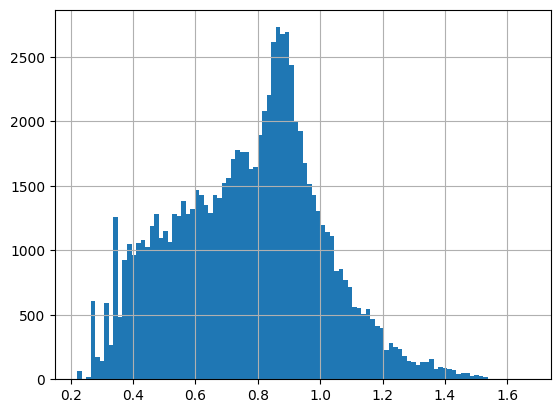

In [183]:
df['dist_entropy'].hist(bins=100)

In [186]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor

scaler = Pipeline(
    [
        ('robust', RobustScaler(unit_variance=True)),
        ('minmax', StandardScaler()),
    ]
)

x = scaler.fit_transform(df[["day_forecast_strike_dev", "dist_entropy"]])
y = df["outcome"]
knn = KNeighborsClassifier(n_neighbors=250)
knn.fit(x, y)

curve = knn.predict_proba(x)

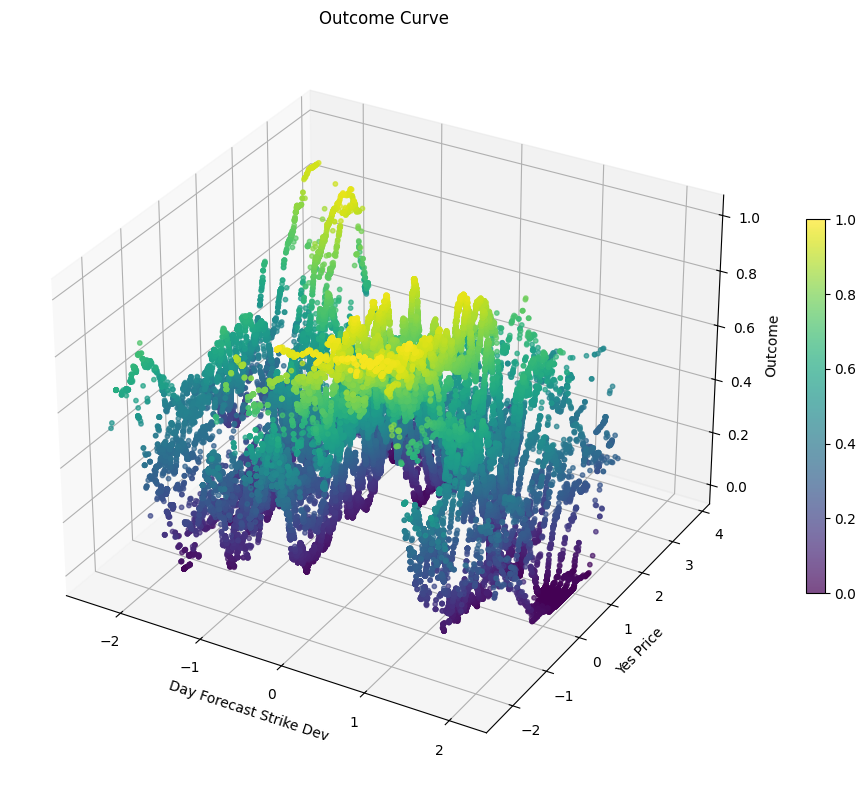

In [187]:
import matplotlib.pyplot as plt

def plot_surface(x, z):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x[:, 0], x[:, 1], z, c=z, s=10, alpha=0.7)
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)

    plt.ion()

    ax.set_xlabel('Day Forecast Strike Dev')
    ax.set_ylabel('Yes Price')
    ax.set_zlabel('Outcome')
    ax.set_title('Outcome Curve')
    plt.tight_layout()
    plt.show()

plot_surface(x, curve[:, 1])

In [134]:
import plotly.graph_objects as go


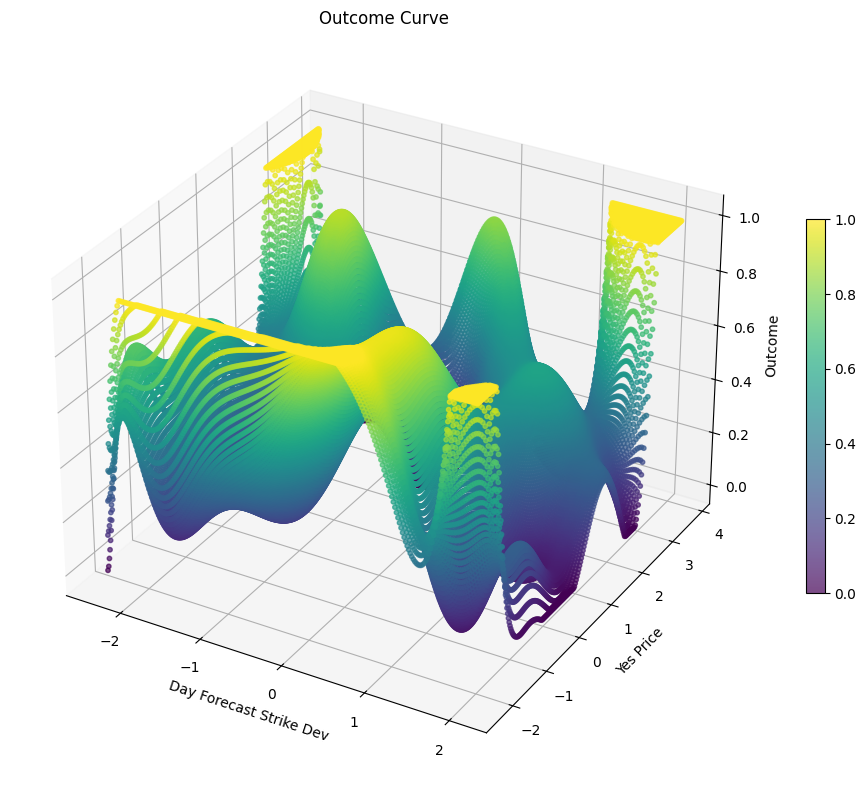

In [188]:
# fit 3d curve to the data
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge

def fit_surface(x, z, degree=3):
    # Create a pipeline for polynomial features and linear regression
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    pipeline.fit(x, z)
    return pipeline

surface = fit_surface(x, curve[:, 1], degree=10)


granularity = 250
_x = np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), granularity)
_y = np.linspace(np.min(x[:, 1]), np.max(x[:, 1]), granularity)

_x, _y = np.meshgrid(_x, _y)
_x_y = np.column_stack((_x.ravel(), _y.ravel()))
z = np.clip(surface.predict(_x_y), 0, 1)

plot_surface(_x_y, z)


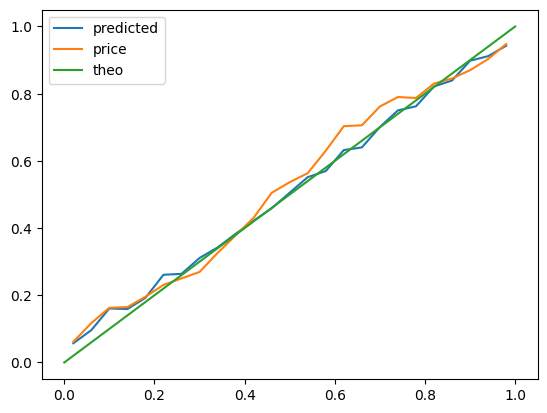

In [210]:
pipeline = Pipeline([
    ('robust', RobustScaler(unit_variance=True)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=500)),
])

features = [
    'yes_price',
    # 'day_forecast_strike_dev',
    # 'kalshi_day_forecast_dev',
    # 'time_to_strike',
]

pipeline.fit(df[features], df['outcome'])

df['pred'] = pipeline.predict_proba(df[features])[:, 1]

buckets = []
space = np.linspace(0, 1, 26)
for i in range(len(space) - 1):
    buckets.append([space[i], space[i + 1]])

x, y, prices = [], [], []
for bucket in buckets:
    y.append(df[(df['pred'] >= bucket[0]) & (df['pred'] < bucket[1])]['outcome'].mean())
    x.append((bucket[0] + bucket[1]) / 2)
    prices.append(df[(df['pred'] >= bucket[0]) & (df['pred'] < bucket[1])]['yes_price'].mean() / 100)

plt.plot(x, y, label='predicted')
plt.plot(x, prices, label='price')
plt.plot([0, 1], [0, 1], label='theo')
plt.legend()
plt.show()

